**1) Monter Google Drivetexte en gras**

In [26]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


2) **Imports**

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

**3) Configuration générale**

In [28]:
# ==============================
# CONFIGURATION GENERALE
# ==============================
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

DATASET_DIR = Path("/content/drive/MyDrive/tous_mes_documents (1)/dataset")
MODELS_DIR = Path("/content/drive/MyDrive/tous_mes_documents (1)/models_version2")
MODELS_DIR.mkdir(parents=True, exist_ok=True)

FEATURE_COLUMNS = ["aX", "aY", "aZ", "gX", "gY", "gZ"]

CLASS_FILES = {
    "no_vibration": "no_vibration.csv",
    "low_vibration": "low_vibration.csv",
    "high_vibration": "high_vibration.csv"
}

label_to_id = {label: idx for idx, label in enumerate(CLASS_FILES.keys())}
id_to_label = {idx: label for label, idx in label_to_id.items()}

WINDOW_SIZE = 100
STRIDE = 25

print("Dataset folder :", DATASET_DIR)
print("Models folder  :", MODELS_DIR)
print("Classes        :", label_to_id)

Dataset folder : /content/drive/MyDrive/tous_mes_documents (1)/dataset
Models folder  : /content/drive/MyDrive/tous_mes_documents (1)/models_version2
Classes        : {'no_vibration': 0, 'low_vibration': 1, 'high_vibration': 2}


**Vérifier les fichiers**

In [29]:
missing_files = []

for class_name, file_name in CLASS_FILES.items():
    file_path = DATASET_DIR / file_name
    if not file_path.exists():
        missing_files.append(str(file_path))

if missing_files:
    raise FileNotFoundError("Missing files:\n" + "\n".join(missing_files))

print("All dataset files found ✅")
print(list(DATASET_DIR.glob("*.csv")))

All dataset files found ✅
[PosixPath('/content/drive/MyDrive/tous_mes_documents (1)/dataset/low_vibration.csv'), PosixPath('/content/drive/MyDrive/tous_mes_documents (1)/dataset/high_vibration.csv'), PosixPath('/content/drive/MyDrive/tous_mes_documents (1)/dataset/no_vibration.csv')]


**5) Charger les CSV**

In [30]:
def load_imu_csv(csv_path, columns):
    df = pd.read_csv(csv_path)
    df = df[columns].dropna().reset_index(drop=True)
    return df.to_numpy(dtype=np.float32)

raw_signals = {}

for class_name, file_name in CLASS_FILES.items():
    file_path = DATASET_DIR / file_name
    raw_signals[class_name] = load_imu_csv(file_path, FEATURE_COLUMNS)
    print(f"{class_name}: {raw_signals[class_name].shape}")

no_vibration: (4388, 6)
low_vibration: (4414, 6)
high_vibration: (4366, 6)


**6) Afficher un aperçu**

In [31]:
for class_name, signal in raw_signals.items():
    print(f"\nClass: {class_name}")
    print("Shape:", signal.shape)
    print(signal[:5])


Class: no_vibration
Shape: (4388, 6)
[[-0.191  0.023  0.953 -0.427  1.038 -0.061]
 [-0.188  0.026  0.954 -0.916  1.221  0.183]
 [-0.158  0.029  0.954 -0.549  1.648 -0.183]
 [-0.184  0.024  0.951 -0.793  1.77   0.366]
 [-0.183  0.021  0.953 -1.465  1.892 -0.366]]

Class: low_vibration
Shape: (4414, 6)
[[-0.132 -0.045  0.967  1.282  1.16   1.892]
 [-0.087 -0.003  0.961  0.732  1.587  1.587]
 [-0.042  0.005  0.96   0.977  1.953  1.038]
 [-0.07  -0.033  0.967  0.977  1.709  1.953]
 [-0.066 -0.025  0.965  1.282  1.404  1.404]]

Class: high_vibration
Shape: (4366, 6)
[[-3.210e-01 -9.510e-01 -2.000e-03  3.845e+00  3.235e+00  4.272e+00]
 [-3.090e-01 -9.610e-01  1.300e-02  1.709e+00  3.479e+00  4.822e+00]
 [-2.980e-01 -9.710e-01  6.000e-03 -6.100e-02  3.296e+00  3.601e+00]
 [-2.800e-01 -9.500e-01  7.000e-03 -2.136e+00  5.005e+00  2.747e+00]
 [-3.310e-01 -9.580e-01  2.200e-02  2.625e+00  5.981e+00  3.235e+00]]


**7) Visualiser les signaux**

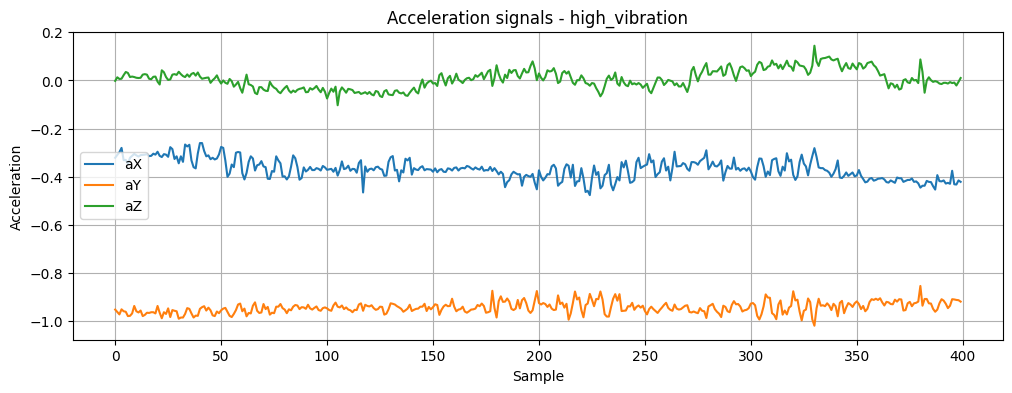

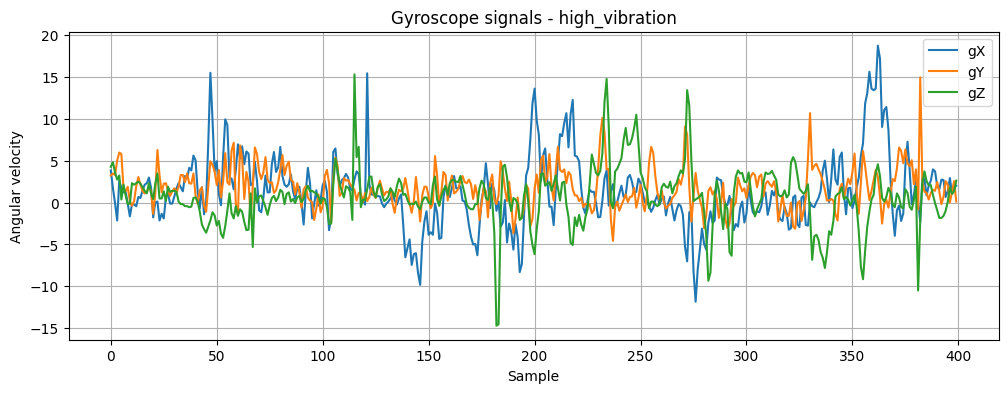

In [32]:
example_class = "high_vibration"
signal = raw_signals[example_class]

plt.figure(figsize=(12, 4))
plt.plot(signal[:400, 0], label="aX")
plt.plot(signal[:400, 1], label="aY")
plt.plot(signal[:400, 2], label="aZ")
plt.title(f"Acceleration signals - {example_class}")
plt.xlabel("Sample")
plt.ylabel("Acceleration")
plt.grid()
plt.legend()
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(signal[:400, 3], label="gX")
plt.plot(signal[:400, 4], label="gY")
plt.plot(signal[:400, 5], label="gZ")
plt.title(f"Gyroscope signals - {example_class}")
plt.xlabel("Sample")
plt.ylabel("Angular velocity")
plt.grid()
plt.legend()
plt.show()

**8)Comparer les classes**

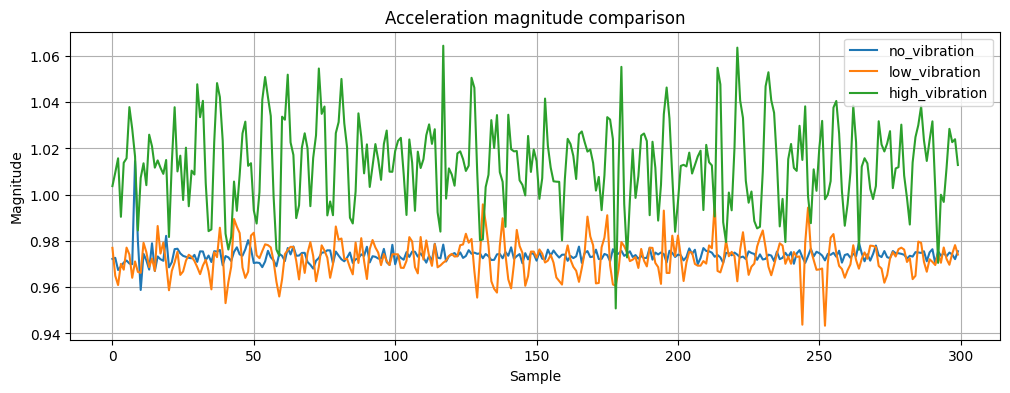

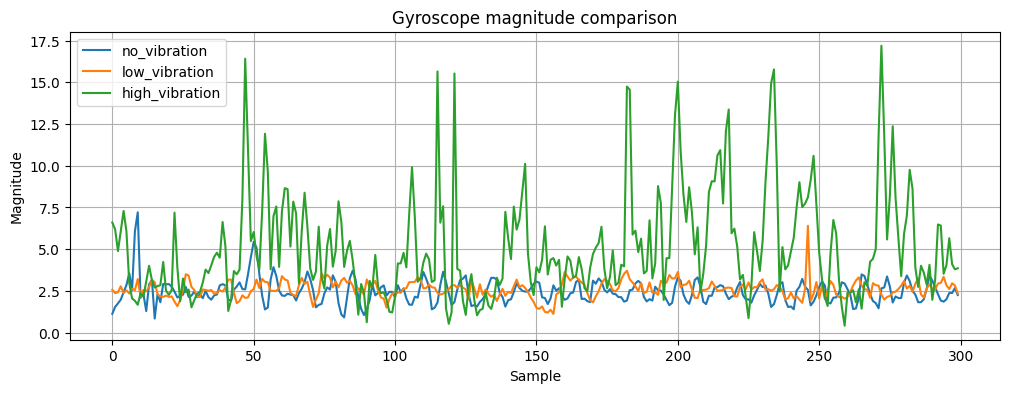

In [33]:
N = 300

plt.figure(figsize=(12, 4))
for class_name, signal in raw_signals.items():
    acc_mag = np.sqrt(signal[:N, 0]**2 + signal[:N, 1]**2 + signal[:N, 2]**2)
    plt.plot(acc_mag, label=class_name)

plt.title("Acceleration magnitude comparison")
plt.xlabel("Sample")
plt.ylabel("Magnitude")
plt.grid()
plt.legend()
plt.show()

plt.figure(figsize=(12, 4))
for class_name, signal in raw_signals.items():
    gyro_mag = np.sqrt(signal[:N, 3]**2 + signal[:N, 4]**2 + signal[:N, 5]**2)
    plt.plot(gyro_mag, label=class_name)

plt.title("Gyroscope magnitude comparison")
plt.xlabel("Sample")
plt.ylabel("Magnitude")
plt.grid()
plt.legend()
plt.show()

**9) Découper en fenêtres glissantes**

In [34]:
def create_windows(signal, window_size=100, stride=25):
    windows = []
    n_samples = signal.shape[0]

    for start in range(0, n_samples - window_size + 1, stride):
        end = start + window_size
        windows.append(signal[start:end])

    if len(windows) == 0:
        return np.zeros((0, window_size, signal.shape[1]), dtype=np.float32)

    return np.stack(windows).astype(np.float32)

**10) Extraire des features statistiques**

In [35]:
def extract_window_features(window):
    acc = window[:, 0:3]
    gyro = window[:, 3:6]

    acc_mag = np.sqrt(np.sum(acc ** 2, axis=1))
    gyro_mag = np.sqrt(np.sum(gyro ** 2, axis=1))

    mean_acc = np.mean(acc_mag)
    std_acc = np.std(acc_mag)
    max_acc = np.max(acc_mag)

    mean_gyro = np.mean(gyro_mag)
    std_gyro = np.std(gyro_mag)
    max_gyro = np.max(gyro_mag)

    return np.array([
        mean_acc,
        std_acc,
        max_acc,
        mean_gyro,
        std_gyro,
        max_gyro
    ], dtype=np.float32)

**11) Construire le dataset final X, y**

In [36]:
def build_feature_dataset(raw_signals, label_to_id, window_size=100, stride=25):
    X_list = []
    y_list = []

    for class_name, class_id in label_to_id.items():
        signal = raw_signals[class_name]
        windows = create_windows(signal, window_size=window_size, stride=stride)

        print(f"{class_name}: {len(windows)} windows")

        for window in windows:
            features = extract_window_features(window)
            X_list.append(features)
            y_list.append(class_id)

    X = np.array(X_list, dtype=np.float32)
    y = np.array(y_list, dtype=np.int32)

    return X, y

X, y = build_feature_dataset(
    raw_signals=raw_signals,
    label_to_id=label_to_id,
    window_size=WINDOW_SIZE,
    stride=STRIDE
)

print("X shape:", X.shape)
print("y shape:", y.shape)

no_vibration: 172 windows
low_vibration: 173 windows
high_vibration: 171 windows
X shape: (516, 6)
y shape: (516,)


**12) Séparer train / validation / test**

In [37]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.4,
    random_state=SEED,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=SEED,
    stratify=y_temp
)

print("Train:", X_train.shape, y_train.shape)
print("Val  :", X_val.shape, y_val.shape)
print("Test :", X_test.shape, y_test.shape)

Train: (309, 6) (309,)
Val  : (103, 6) (103,)
Test : (104, 6) (104,)


**13) Normaliser les données**

In [38]:
feature_mean = np.mean(X_train, axis=0)
feature_std = np.std(X_train, axis=0) + 1e-6

X_train = (X_train - feature_mean) / feature_std
X_val   = (X_val   - feature_mean) / feature_std
X_test  = (X_test  - feature_mean) / feature_std

np.save(MODELS_DIR / "mean.npy", feature_mean)
np.save(MODELS_DIR / "std.npy", feature_std)

print("Normalization saved ✅")
print("mean:", feature_mean)
print("std :", feature_std)

Normalization saved ✅
mean: [9.8630977e-01 1.1053785e-02 1.0176578e+00 3.6511772e+00 1.8860983e+00
 1.1553358e+01]
std : [1.8467149e-02 8.9842714e-03 4.1856475e-02 1.7437330e+00 2.3633788e+00
 1.2441247e+01]


**14) Créer le modèle**

In [39]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(6,)),
    tf.keras.layers.Dense(16, activation="relu"),
    tf.keras.layers.Dropout(0.15),
    tf.keras.layers.Dense(8, activation="relu"),
    tf.keras.layers.Dense(len(CLASS_FILES), activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 16)             │           112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 275 (1.07 KB)

 Trainable params: 275 (1.07 KB)

 Non-trainable params: 0 (0.00 B)

**15) Entraîner le modèle**

In [40]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=70,
    batch_size=8,
    verbose=1
)

Epoch 1/70
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.4403 - loss: 1.0966 - val_accuracy: 0.9417 - val_loss: 0.9444
Epoch 2/70
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6568 - loss: 0.9414 - val_accuracy: 0.9126 - val_loss: 0.8397
Epoch 3/70
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7609 - loss: 0.8315 - val_accuracy: 0.8641 - val_loss: 0.7156
Epoch 4/70
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8064 - loss: 0.7163 - val_accuracy: 0.8835 - val_loss: 0.5864
Epoch 5/70
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8468 - loss: 0.5813 - val_accuracy: 0.9417 - val_loss: 0.4744
Epoch 6/70
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8442 - loss: 0.5296 - val_accuracy: 0.9515 - val_loss: 0.3940
Epoch 7/70
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8785 - loss: 0.4467 - val_accuracy: 0.9709 - val_loss: 0.3371
Epoch 8/70
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9187 - loss: 0.3809 - val_accuracy: 0.9806 - val_loss

**16) Afficher les courbes**

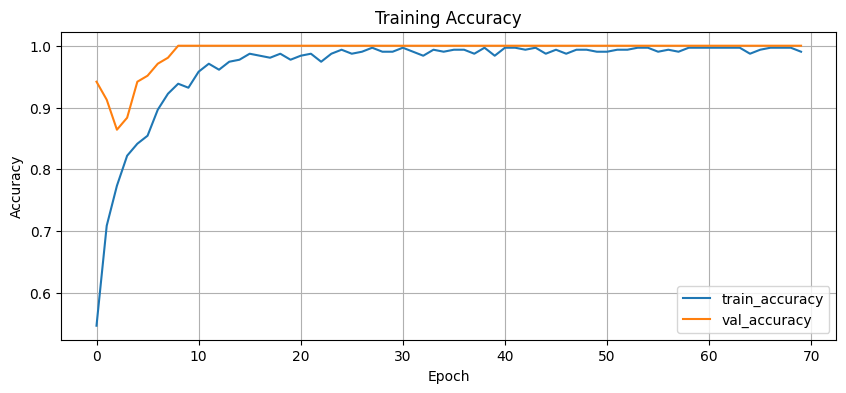

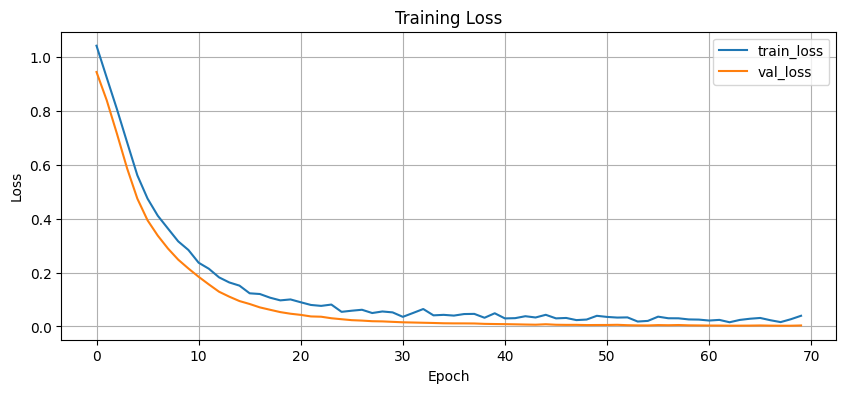

In [41]:
plt.figure(figsize=(10, 4))
plt.plot(history.history["accuracy"], label="train_accuracy")
plt.plot(history.history["val_accuracy"], label="val_accuracy")
plt.title("Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid()
plt.legend()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(history.history["loss"], label="train_loss")
plt.plot(history.history["val_loss"], label="val_loss")
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid()
plt.legend()
plt.show()

**17) Évaluer le modèle**

In [42]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print("Test accuracy:", test_acc)
print("Test loss:", test_loss)

Test accuracy: 1.0
Test loss: 0.008111356757581234


**18) Matrice de confusion**

In [43]:
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

cm = confusion_matrix(y_test, y_pred)
print("Confusion matrix:")
print(cm)

print("\nClassification report:")
print(classification_report(y_test, y_pred, target_names=list(CLASS_FILES.keys())))

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
Confusion matrix:
[[34  0  0]
 [ 0 35  0]
 [ 0  0 35]]

Classification report:
                precision    recall  f1-score   support

  no_vibration       1.00      1.00      1.00        34
 low_vibration       1.00      1.00      1.00        35
high_vibration       1.00      1.00      1.00        35

      accuracy                           1.00       104
     macro avg       1.00      1.00      1.00       104
  weighted avg       1.00      1.00      1.00       104



**19) Sauvegarder le modèle Keras**

In [44]:
keras_path = MODELS_DIR / "vibration_classifier.keras"
model.save(keras_path)
print("Keras model saved:", keras_path)

Keras model saved: /content/drive/MyDrive/tous_mes_documents (1)/models_version2/vibration_classifier.keras


**20) Convertir en TensorFlow Lite**

In [45]:
tflite_path = MODELS_DIR / "vibration_model.tflite"

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]

tflite_model = converter.convert()

with open(tflite_path, "wb") as f:
    f.write(tflite_model)

print("TFLite model saved ✅")
print("Path:", tflite_path)
print("Size:", len(tflite_model), "bytes")

Saved artifact at '/tmp/tmp6h51_q16'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 6), dtype=tf.float32, name='keras_tensor_5')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  134460423210000: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134460423209040: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134460423219600: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134460423223632: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134460423222480: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134460423221904: TensorSpec(shape=(), dtype=tf.resource, name=None)
TFLite model saved ✅
Path: /content/drive/MyDrive/tous_mes_documents (1)/models_version2/vibration_model.tflite
Size: 3220 bytes


**21) Vérifier le modèle TFLite**

In [46]:
interpreter = tf.lite.Interpreter(model_path=str(tflite_path))
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print("Input details :", input_details)
print("Output details:", output_details)

Input details : [{'name': 'serving_default_keras_tensor_5:0', 'index': 0, 'shape': array([1, 6], dtype=int32), 'shape_signature': array([-1,  6], dtype=int32), 'dtype': <class 'numpy.float32'>, 'quantization': (0.0, 0), 'quantization_parameters': {'scales': array([], dtype=float32), 'zero_points': array([], dtype=int32), 'quantized_dimension': 0}, 'sparsity_parameters': {}}]
Output details: [{'name': 'StatefulPartitionedCall_1:0', 'index': 10, 'shape': array([1, 3], dtype=int32), 'shape_signature': array([-1,  3], dtype=int32), 'dtype': <class 'numpy.float32'>, 'quantization': (0.0, 0), 'quantization_parameters': {'scales': array([], dtype=float32), 'zero_points': array([], dtype=int32), 'quantized_dimension': 0}, 'sparsity_parameters': {}}]


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


**22) Générer model_data.h**

In [47]:
MODEL_PATH = MODELS_DIR / "vibration_model.tflite"
HEADER_PATH = MODELS_DIR / "model_data.h"

model_bytes = MODEL_PATH.read_bytes()

with open(HEADER_PATH, "w", encoding="utf-8") as f:
    f.write("// Auto-generated TensorFlow Lite model\n")
    f.write("#pragma once\n\n")
    f.write("const unsigned char model_data[] = {\n")

    for i, b in enumerate(model_bytes):
        f.write(f"0x{b:02x}, ")
        if (i + 1) % 12 == 0:
            f.write("\n")

    f.write("\n};\n")
    f.write(f"const unsigned int model_data_len = {len(model_bytes)};\n")

print("model_data.h generated ✅")
print("Path:", HEADER_PATH)

model_data.h generated ✅
Path: /content/drive/MyDrive/tous_mes_documents (1)/models_version2/model_data.h


**23) Sauvegarder les labels**

In [48]:
labels_path = MODELS_DIR / "labels.txt"

with open(labels_path, "w", encoding="utf-8") as f:
    for label in CLASS_FILES.keys():
        f.write(label + "\n")

print("labels.txt saved:", labels_path)

labels.txt saved: /content/drive/MyDrive/tous_mes_documents (1)/models_version2/labels.txt
